# A data-driven assessment of Continuum of Care (CoC) effectiveness in addressing homelessness among older adults (65+) in California

Methodology Overview:
1.  **Data Integration:** Load and integrate multiple datasets, including CoC
    geospatial data, census population figures, Zillow Home Value Index (ZHVI),
    and Point-in-Time (PIT) homelessness counts.
2.  **CoC Mapping:** Programmatically map each CoC to its constituent counties 
    and/or cities to enable accurate data aggregation.
3.  **Feature Engineering:** Construct the dependent and independent variables:
    - Dependent Variable: Count of homeless individuals aged 65+ in 2023.
    - Independent Variables: CoC population (and its log), population-weighted ZHVI,
      geographical coordinates (centroids), and a spatial lag term representing
      homelessness in neighboring CoCs.
4.  **Modeling and Evaluation:**
    - Analyze the impact of different feature combinations on model performance.
    - Compare the predictive accuracy of an ANCOVA (linear model) and a
      Random Forest Regressor.
5.  **Prediction Set Analysis:** Generate predictions on a synthetic dataset where
    population is held constant to isolate the effects of other variables.
6.  **Visualization:** Generate clean, paper-ready plots for results.Methodology Overview:
1.  **Data Integration:** Load and integrate multiple datasets, including CoC
    geospatial data, census population figures, Zillow Home Value Index (ZHVI),
    and Point-in-Time (PIT) homelessness counts.
2.  **CoC Mapping:** Programmatically map each CoC to its constituent counties 
    and/or cities to enable accurate data aggregation.
3.  **Feature Engineering:** Construct the dependent and independent variables:
    - Dependent Variable: Count of homeless individuals aged 65+ in 2023.
    - Independent Variables: CoC population (and its log), population-weighted ZHVI,
      geographical coordinates (centroids), and a spatial lag term representing
      homelessness in neighboring CoCs.
4.  **Modeling and Evaluation:**
    - Analyze the impact of different feature combinations on model performance.
    - Compare the predictive accuracy of an ANCOVA (linear model) and a
      Random Forest Regressor.
5.  **Visualization:** Generate clean, paper-ready plots for results.

## 1. Setup and Imports

In [3]:
import os
import re
from itertools import combinations
import numpy as np
import pandas as pd
import geopandas as gpd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns

In [5]:
# Configure plot style for publications
sns.set_context("paper", font_scale=1.2)
sns.set_style("whitegrid")

## 2. Data Loading and Initial Cleaning

In [8]:
# Define file paths
DATA_DIR = "data"
COC_SHAPEFILE_DIR = os.path.join(DATA_DIR, "California")
COUNTY_ZHVI_PATH = os.path.join(DATA_DIR, "County_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv")
CITY_ZHVI_PATH = os.path.join(DATA_DIR, "City_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv")
CENSUS_PATH = os.path.join(DATA_DIR, "census-ca-2020-2024.csv")
PIT_COUNT_PATH = os.path.join(DATA_DIR, "cy_age.csv")

In [10]:
# Load Datasets
county_zhvi_df = pd.read_csv(COUNTY_ZHVI_PATH)
city_zhvi_df = pd.read_csv(CITY_ZHVI_PATH)
census_df = pd.read_csv(CENSUS_PATH)
pit_df = pd.read_csv(
    PIT_COUNT_PATH,
    na_values="*",
    dtype={
        "AGE_GROUP_PUBLIC": pd.CategoricalDtype(
            categories=[
                "Under 18",
                "18-24",
                "25-34",
                "35-44",
                "45-54",
                "55-64",
                "65+",
                # Ignore Unknown and Invalid categories
                # "Unknown",
                # "Invalid",
            ],
            ordered=True,
        ),
    },
).dropna()

# Load and concatenate all CoC shapefiles
shapefile_paths = [
    os.path.join(COC_SHAPEFILE_DIR, f, f"{f}.shp")
    for f in os.listdir(COC_SHAPEFILE_DIR)
    if f.startswith("CA_")
]
coc_gdf = pd.concat([gpd.read_file(shp) for shp in shapefile_paths], ignore_index=True)

In [12]:
def clean_name(name):
    """
    Standardize CoC names from different sources to either:
    - a comma-separated list of counties
    - a county name
    - a city name
    """
    name = name.replace(' CoC', '')
    name = name.replace(' City & County/', ', ')
    name = re.sub(r'[^/]*\/', '', name) # strip redundant city lists before a slash
    name = name.replace('City & County', '').replace('City and County', '').strip()
    name = name.replace('(Los Angeles)', '').replace('(Los Angeles County)', '').strip()
    return name.replace(' County', '').replace(' Counties', '').replace(' City', '').strip()

In [14]:
# Clean Point-in-Time (PIT) data
pit_df.rename(columns={
    'CALENDAR_YEAR': 'Year',
    'LOCATION': 'CoC_Name',
    'AGE_GROUP_PUBLIC': 'Age',
    'EXPERIENCING_HOMELESSNESS_CNT': 'Homeless count'
}, inplace=True)
pit_df['CoC_Name'] = pit_df['CoC_Name'].apply(clean_name)

Use _geography_ for either city or county.

In [16]:
# Clean Census data
census_df.rename(columns={'County': 'Geography'}, inplace=True)
census_df['Geography'] = census_df['Geography'].apply(clean_name)

In [18]:
# Clean Zillow Home Value Index (ZHVI) data
county_zhvi_df['RegionName'] = county_zhvi_df['RegionName'].apply(clean_name)
city_zhvi_df['RegionName'] = city_zhvi_df['RegionName'].apply(clean_name)

In [20]:
# Clean and standardize CoC GeoDataFrame
coc_gdf.rename(columns={'COCNAME': 'CoC_Name'}, inplace=True)
coc_gdf['CoC_Name'] = coc_gdf['CoC_Name'].apply(clean_name)

## 3. CoC to Geography Mapping and Population Aggregation (Paper Sections 2.1, 2.2.1)

In [22]:
# Get a list of all counties in California from the census data
ca_counties = set(census_df['Geography'])

In [24]:
def get_geographies_from_coc(coc_name):
    """
    Parses a CoC name to extract constituent geographies (counties or cities).
    """
    geographies = []
    
    # Split by common delimiters for multi-geography CoCs
    potential_geos = re.split(r', | and ', clean_name(coc_name))
    
    for geo in potential_geos:
        if geo: # Ensure we don't add empty strings
            geo_type = 'County' if geo in ca_counties else 'City'
            geographies.append({'Geography': geo, 'Type': geo_type})
    return geographies

In [26]:
# Create a long-format DataFrame mapping each CoC to its constituent geographies
coc_geo_map_list = []
for _, row in coc_gdf.iterrows():
    geos = get_geographies_from_coc(row['CoC_Name'])
    for geo_info in geos:
        coc_geo_map_list.append({
            'CoC_Name': row['CoC_Name'],
            'Geography': geo_info['Geography'],
            'Type': geo_info['Type']
        })
coc_geo_map = pd.DataFrame(coc_geo_map_list).drop_duplicates().reset_index(drop=True)

In [28]:
# Aggregate Population Data to CoC Level
# Note: City populations are not in census_df, so we only join on counties.
coc_pop = pd.merge(coc_geo_map[coc_geo_map['Type'] == 'County'], census_df, on='Geography', how='left')
coc_population_df = coc_pop.groupby('CoC_Name')[[str(year) for year in range(2020, 2024)]].sum().reset_index()
coc_pop.drop(columns=['Type', 'Base'], inplace=True)
coc_map = coc_pop.melt(id_vars=['CoC_Name', 'Geography'], var_name='Year', value_name='Population')
coc_map['Year'] = pd.to_numeric(coc_map.Year, errors='coerce')
coc_population_df = coc_population_df.melt(id_vars=['CoC_Name'], var_name='Year', value_name='Population')
coc_population_df['Year'] = pd.to_numeric(coc_population_df.Year, errors='coerce')

In [30]:
# Source: ACS 1/5-Year Estimates Detailed Tables
city_coc_population_df = pd.DataFrame(
    columns=['CoC_Name', 'Year', 'Population'],
    data=[
        ['Glendale',   2020, 199357],
        ['Glendale',   2021, 196512],
        ['Glendale',   2022, 194512],
        ['Glendale',   2023, 192270],
        ['Long Beach', 2020, 462081],
        ['Long Beach', 2021, 466565],
        ['Long Beach', 2022, 462293],
        ['Long Beach', 2023, 458491],
        ['Pasadena',   2020, 273328],
        ['Pasadena',   2021, 271732],
        ['Pasadena',   2022, 268832],
        ['Pasadena',   2023, 266090],
    ],
)

In [32]:
coc_population_df = pd.concat((coc_population_df, city_coc_population_df))

# Subtract LA's city-level CoCs population from LA's county-wide CoC
coc_population_df.loc[coc_population_df.CoC_Name == 'Los Angeles', 'Population'] = \
    coc_population_df.loc[coc_population_df.CoC_Name == 'Los Angeles', 'Population'] \
    - coc_population_df.loc[coc_population_df.CoC_Name == "Glendale", 'Population'].to_numpy() \
    - coc_population_df.loc[coc_population_df.CoC_Name == "Long Beach", 'Population'].to_numpy() \
    - coc_population_df.loc[coc_population_df.CoC_Name == "Pasadena", 'Population'].to_numpy()

In [34]:
city_coc_population_df['Geography'] = city_coc_population_df['CoC_Name']
coc_map = pd.concat((coc_map, city_coc_population_df))

## 4. Feature Engineering (Paper Section 2.2)

### 4.1 Dependent Variable: Homelessness Count

Especially want to predict for age group 65+ in 2023

In [36]:
homelessness_df = pit_df[
    (pit_df["Year"] >= 2020)
    & (pit_df["Year"] <= 2023)
    & (pit_df["CoC_Name"] != "California")
    & (pit_df["Age"] != "Invalid")
    & (pit_df["Age"] != "Unknown")
]
homelessness_df = homelessness_df[["CoC_Name", "Year", "Age", "Homeless count"]]

### 4.2 Independent Variables

In [39]:
# --- Housing Price Data (ZHVI - Section 2.2.2) ---
def get_mean_zhvi_for_year(zhvi_df, year):
    """Extracts and calculates the mean ZHVI for a given year."""
    year_cols = [c for c in zhvi_df.columns if c.startswith(str(year))]
    if not year_cols:
        return pd.DataFrame(columns=['Geography', 'ZHVI'])
    
    zhvi_year = zhvi_df[['RegionName'] + year_cols]
    zhvi_year_melted = zhvi_year.melt(id_vars='RegionName', value_vars=year_cols, value_name='ZHVI')
    mean_zhvi = zhvi_year_melted.groupby('RegionName')['ZHVI'].mean().reset_index()
    return mean_zhvi.rename(columns={'RegionName': 'Geography'})

In [41]:
county_zhvi_df = county_zhvi_df[county_zhvi_df.State=="CA"]
city_zhvi_df = city_zhvi_df[city_zhvi_df.State=="CA"]
city_zhvi_df = city_zhvi_df[(city_zhvi_df.RegionName=="Glendale")|(city_zhvi_df.RegionName=="Long Beach")|(city_zhvi_df.RegionName=="Pasadena")]

In [43]:
zhvi_dfs = []
for year in range(2020, 2024):
    zhvi_county = get_mean_zhvi_for_year(county_zhvi_df, year)
    zhvi_city = get_mean_zhvi_for_year(city_zhvi_df, year)
    zhvi_full = pd.concat([zhvi_county, zhvi_city]).dropna()
    zhvi_full['Year'] = year
    zhvi_dfs.append(zhvi_full)
zhvi_df = pd.concat(zhvi_dfs)

In [45]:
merged_geo_zhvi = pd.merge(coc_geo_map, zhvi_df, on='Geography', how='inner')
merged_abc = pd.merge(merged_geo_zhvi, coc_map, on=['CoC_Name', 'Geography', 'Year'], how='inner')
merged_abc['Numerator'] = merged_abc['Population'] * merged_abc['ZHVI']
grouped_data = merged_abc.groupby(['CoC_Name', 'Year']).agg(
    total_numerator=('Numerator', 'sum'),
    total_denominator=('Population', 'sum')
    # total_denominator=('ZHVI', 'sum')
).reset_index()
grouped_data['Housing cost'] = grouped_data['total_numerator'] / grouped_data['total_denominator']
coc_zhvi_df = grouped_data[['CoC_Name', 'Year', 'Housing cost']]

In [47]:
# --- Geographical Features (Section 2.2.3) ---
# Adjacency Graph
coc_gdf_proj = coc_gdf.to_crs(epsg=3310)  # Project for accurate touches
adjacency = {row.CoC_Name: [] for _, row in coc_gdf_proj.iterrows()}
for index, coc in coc_gdf_proj.iterrows():
    neighbors = coc_gdf_proj[
        coc_gdf_proj.geometry.touches(coc.geometry)
    ].CoC_Name.tolist()
    adjacency[coc.CoC_Name].extend(neighbors)
adjacency_df = pd.DataFrame(
    [
        (name, neighbor)
        for name, neighbors in adjacency.items()
        for neighbor in neighbors
    ],
    columns=["CoC_Name", "Neighbor"],
)

In [48]:
# Centroids (Latitude and Longitude) - calculated on projected CRS, then converted to WGS84
centroids_proj = coc_gdf_proj.geometry.centroid
centroids_wgs84 = centroids_proj.to_crs(epsg=4326)
coc_gdf['Longitude'] = centroids_wgs84.x
coc_gdf['Latitude'] = centroids_wgs84.y

In [51]:
# Spatial Lag
df_neighbor_counts = pd.merge(
    pd.merge(homelessness_df, adjacency_df, on="CoC_Name"),
    homelessness_df.rename(
        columns={"CoC_Name": "Neighbor", "Homeless count": "NeighborCount"}
    ),
    on=["Neighbor", "Year", "Age"],
    how="left",
)
spatial_lag_df = (
    df_neighbor_counts.groupby(["CoC_Name", "Year", "Age"], observed=True)
    .agg(SpatialLag=("NeighborCount", "mean"))
    .reset_index()
    .rename(columns={"SpatialLag": "Spatial lag"})
)

In [53]:
# ## 5. Final DataFrame Assembly
final_df = pd.merge(homelessness_df, coc_population_df, on=['CoC_Name', 'Year'], how='inner')
final_df = pd.merge(final_df, coc_zhvi_df, on=['CoC_Name', 'Year'], how='inner')
final_df = pd.merge(final_df, coc_gdf[['CoC_Name', 'Latitude', 'Longitude']], on='CoC_Name', how='inner')
final_df = pd.merge(final_df, spatial_lag_df, on=['CoC_Name', 'Year', 'Age'], how='inner')

In [55]:
# Clean up and set index
final_df.dropna(inplace=True)
final_df.set_index('CoC_Name', inplace=True)

Final clean DataFrame for modeling

In [57]:
final_df

,Year,Age,Homeless count,Population,Housing cost,Latitude,Longitude,Spatial lag
CoC_Name,,,,,,,,
Santa Clara,2020,18-24,831.0,1924802,1.219541e+06,37.231452,-121.694271,331.166667
Santa Clara,2020,25-34,1729.0,1924802,1.219541e+06,37.231452,-121.694271,636.833333
Santa Clara,2020,35-44,1863.0,1924802,1.219541e+06,37.231452,-121.694271,642.166667
Santa Clara,2020,45-54,1758.0,1924802,1.219541e+06,37.231452,-121.694271,583.000000
Santa Clara,2020,55-64,1880.0,1924802,1.219541e+06,37.231452,-121.694271,623.000000
...,...,...,...,...,...,...,...,...
San Luis Obispo,2023,35-44,564.0,282007,8.529285e+05,35.387193,-120.402484,964.000000
San Luis Obispo,2023,45-54,438.0,282007,8.529285e+05,35.387193,-120.402484,735.250000
San Luis Obispo,2023,55-64,351.0,282007,8.529285e+05,35.387193,-120.402484,657.750000


In [59]:
final_df = final_df.reset_index()

### Normalize continuous features between 0 and 1.

In [62]:
for feature in ['Population', 'Housing cost', 'Latitude', 'Longitude', 'Spatial lag']:
    series = final_df[feature]
    min = series.min()
    max = series.max()
    final_df[f"normalized({feature})"] = (series - min) / (max - min)

## 6. Modeling and Evaluation (Paper Section 2.3)

In [100]:
# Define features and target
TARGET = 'Homeless count'
FEATURES = ['Population', 'Housing cost', 'Latitude', 'Longitude', 'Spatial lag']
X = final_df[FEATURES]
y = final_df[TARGET]

In [102]:
# Define transforms
TRANSFORMS = {
    "log": np.log1p,
    "exp": np.exp,
    "sqrt": np.sqrt,
    "square": np.square,
}

ALL_FEATURES = []
FEATURE_GROUPS = []
for feature in FEATURES:
    ALL_FEATURES.append(feature)
    for transform_name, transform_function in TRANSFORMS.items():
        transformed_feature = f"{transform_name}({feature})"
        final_df[transformed_feature] = transform_function(final_df[f"normalized({feature})"])
        group = [feat if feat != feature else transformed_feature for feat in FEATURES]
        ALL_FEATURES.append(transformed_feature)
        FEATURE_GROUPS.append(group)

### Is it linear?

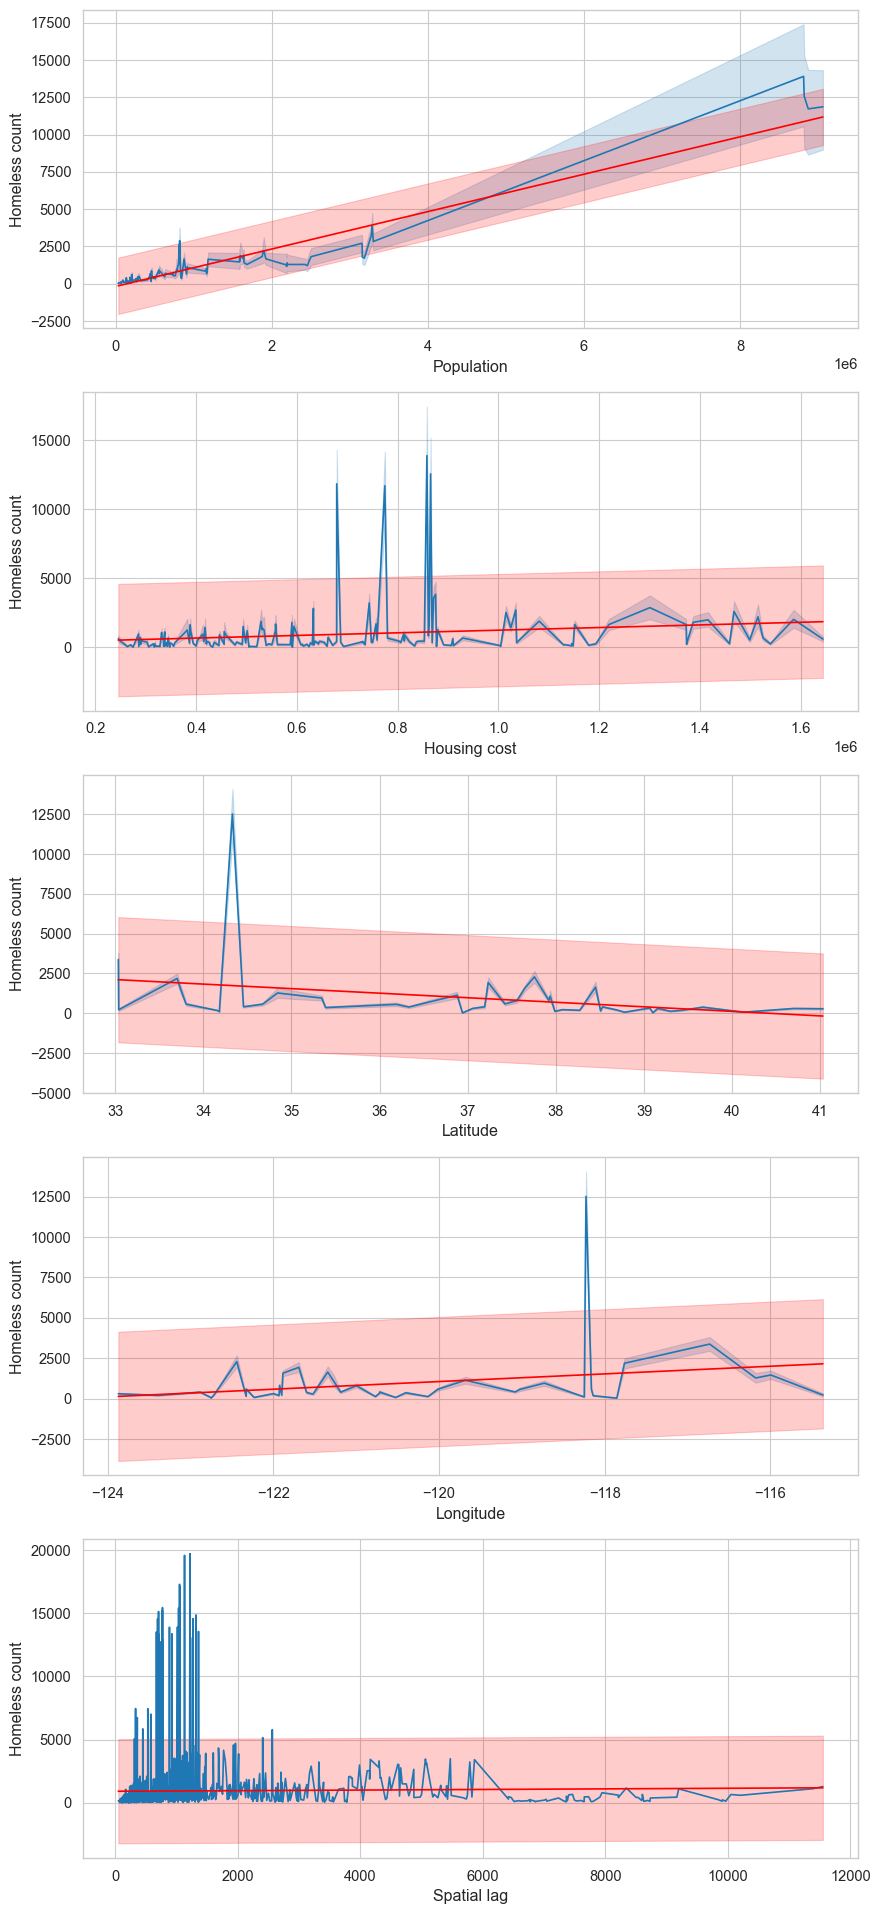

In [105]:
from scipy import stats

plt.figure(figsize=(10,24))
for i, feature in enumerate(FEATURES):

    slope, intercept, r_value, p_value, std_err = stats.linregress(final_df[feature], final_df["Homeless count"])

    Y_pred = slope * final_df[feature] + intercept
    residuals = final_df["Homeless count"] - Y_pred
    se = np.sqrt(np.sum(residuals**2) / (len(final_df[feature]) - 2)) 

    plt.subplot(len(FEATURES), 1, i+1)
    sns.lineplot(final_df, y="Homeless count", x=feature)
    min, max = final_df[feature].min(), final_df[feature].max()
    plt.plot([min, max], [intercept + slope * min, intercept + slope * max], 'r')
    plt.fill_between(
        [min, max],
        [intercept + slope * min + 2*se, intercept + slope * max + 2*se],
        [intercept + slope * min - 2*se, intercept + slope * max - 2*se],
        color='red',
        alpha=0.2,
    )
    plt.xlabel(feature)
    plt.ylabel("Homeless count")


In [107]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(final_df[FEATURES])

X_scaled = scaler.transform(final_df[FEATURES])

In [145]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures

age_dummies = pd.get_dummies(final_df['Age'], prefix='Age')
X_with_age = np.column_stack((X_scaled, age_dummies))
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_interact = poly.fit_transform(X_with_age)

# Fit linear regression model
model = LinearRegression()
model.fit(X_interact, final_df["Homeless count"])
Y_pred = model.predict(X_interact)

rmse = np.sqrt(mean_squared_error(final_df["Homeless count"], Y_pred))
r2 = r2_score(final_df["Homeless count"], Y_pred)
print(f"Training RMSE: {rmse:.2f}")
print(f"Training R^2 Score: {r2:.2f}")

Training RMSE: 467.53
Training R^2 Score: 0.95


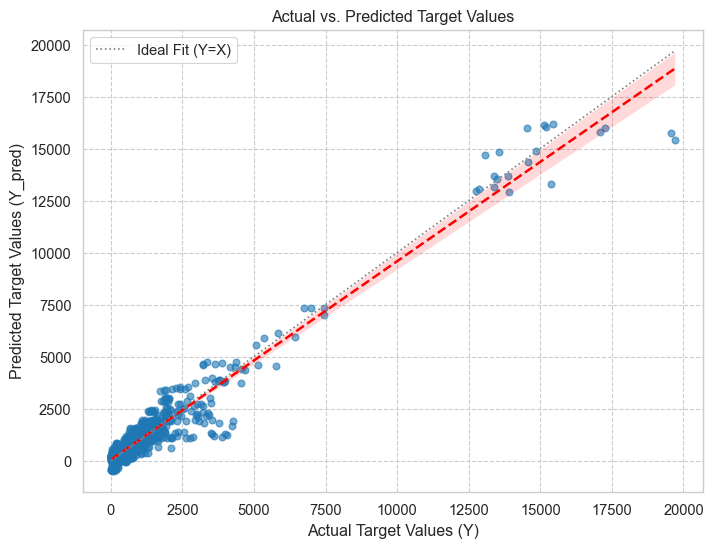

In [147]:
plt.figure(figsize=(8, 6))
sns.regplot(x=final_df["Homeless count"], y=Y_pred, scatter_kws={'alpha':0.6}, line_kws={'color':'red', 'linestyle':'--'})
min, max = final_df["Homeless count"].min(), final_df["Homeless count"].max()
plt.plot([min, max], [min, max], color='gray', linestyle=':', label='Ideal Fit (Y=X)') # Ideal 45-degree line

plt.xlabel("Actual Target Values (Y)")
plt.ylabel("Predicted Target Values (Y_pred)")
plt.title("Actual vs. Predicted Target Values")
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

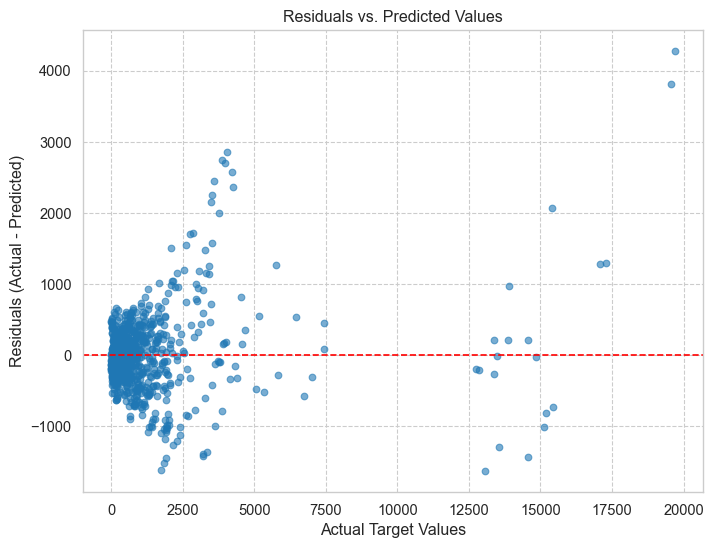

In [163]:
residuals = final_df["Homeless count"] - Y_pred

plt.figure(figsize=(8, 6))
plt.scatter(final_df["Homeless count"], residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--') # Horizontal line at zero
plt.xlabel("Actual Target Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals vs. Predicted Values")
plt.grid(True, linestyle='--')
plt.show()

In [151]:
coefficients_df = pd.DataFrame({'Feature': FEATURES, 'Coefficient': model.coef_})
coefficients_df = coefficients_df.sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coefficients_df)
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Linear Regression Coefficients (Feature Importance)")
plt.show()

ValueError: All arrays must be of the same length

In [183]:
import statsmodels.formula.api as smf

model = smf.ols(
    'Q("Homeless count") ~ (Population + Q("Housing cost") + Latitude + Longitude + Q("Spatial lag") + C(Age))**2',
    data=final_df
).fit()

print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     Q("Homeless count")   R-squared:                       0.946
Model:                             OLS   Adj. R-squared:                  0.944
Method:                  Least Squares   F-statistic:                     465.6
Date:                 Tue, 28 Oct 2025   Prob (F-statistic):               0.00
Time:                         15:22:11   Log-Likelihood:                -9302.6
No. Observations:                 1225   AIC:                         1.870e+04
Df Residuals:                     1180   BIC:                         1.893e+04
Df Model:                           44                                         
Covariance Type:             nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

<Figure size 1000x800 with 0 Axes>

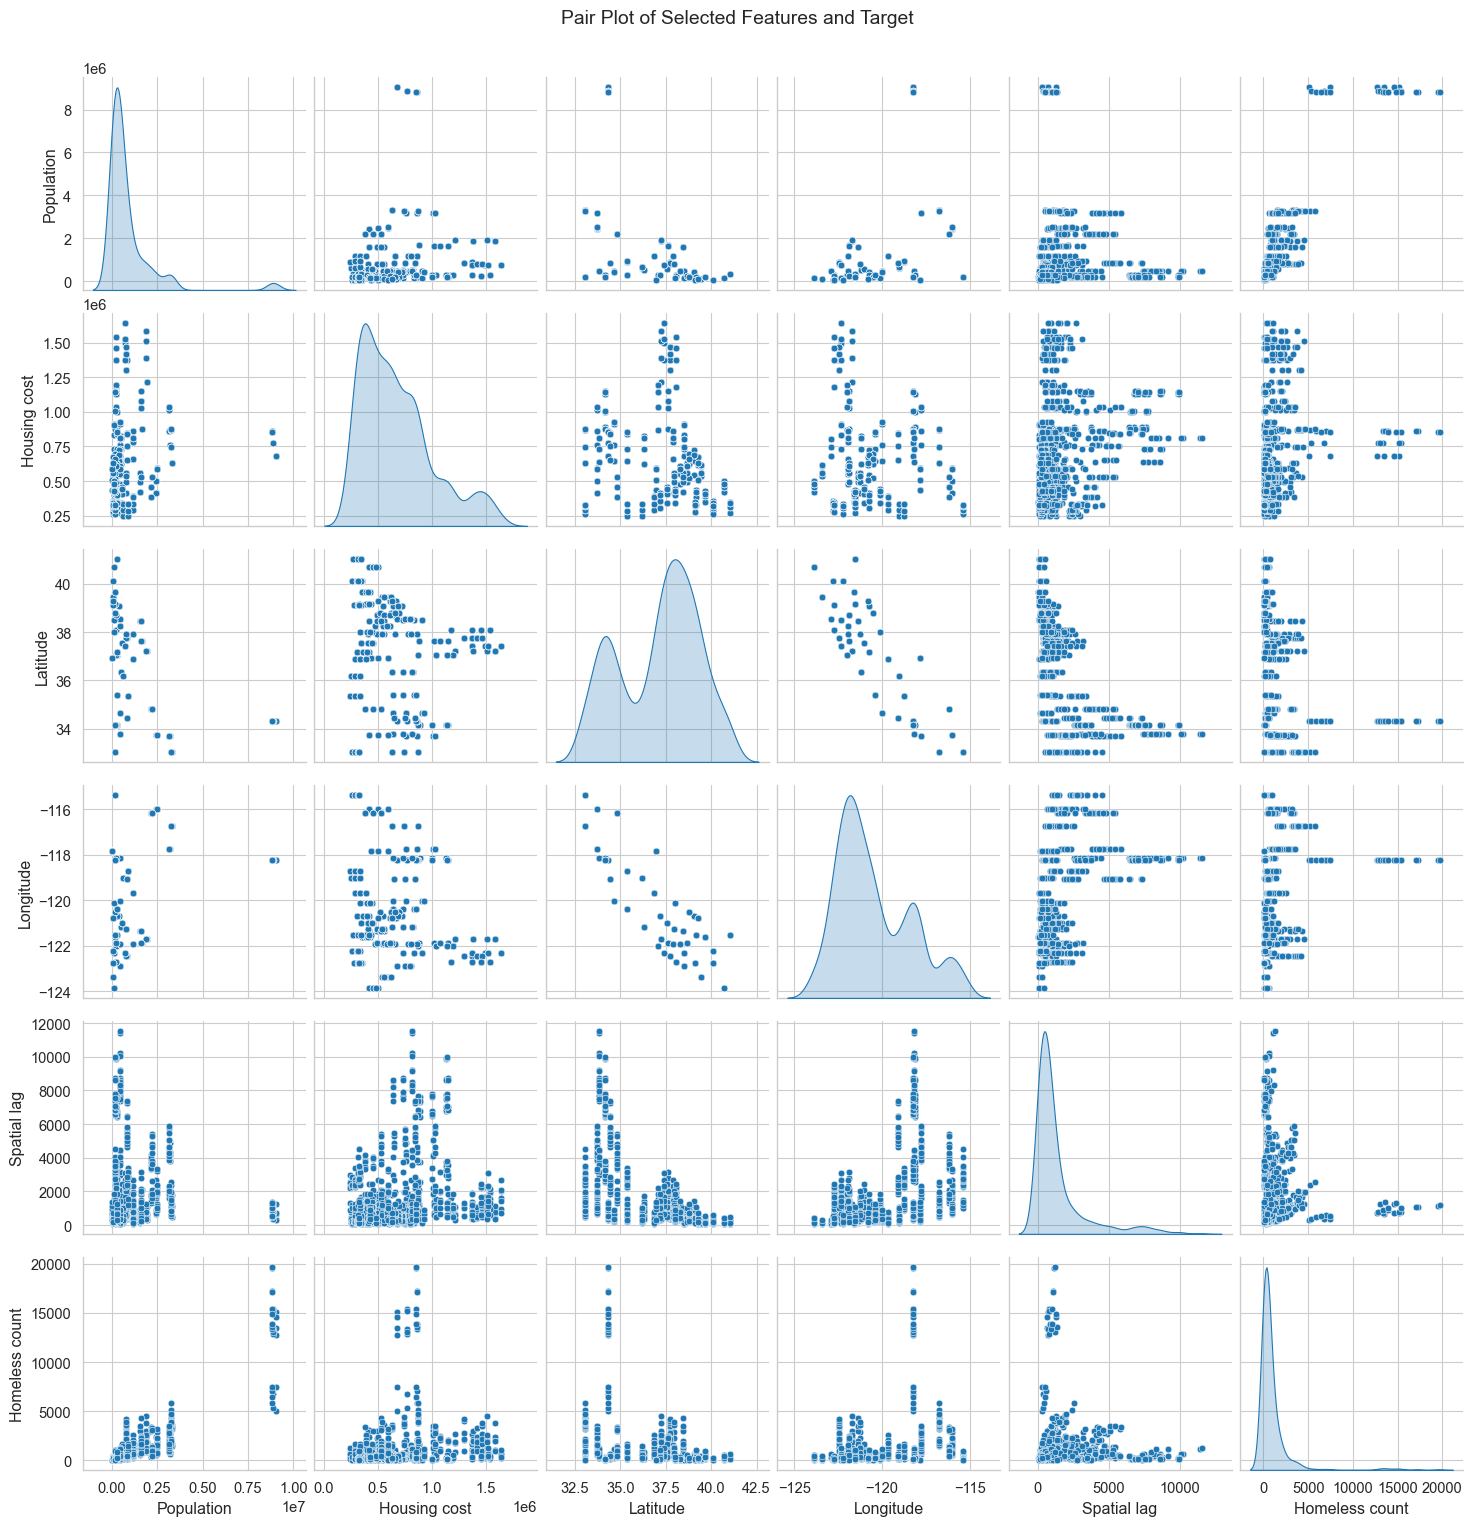

In [133]:
selected_cols = FEATURES + ['Homeless count']

plt.figure(figsize=(10, 8))
sns.pairplot(final_df[selected_cols], diag_kind='kde') # 'kde' for density plot on diagonal
plt.suptitle("Pair Plot of Selected Features and Target", y=1.02) # Adjust title position
plt.show()

Would splitting out more populated CoCs help? Let's try it out.

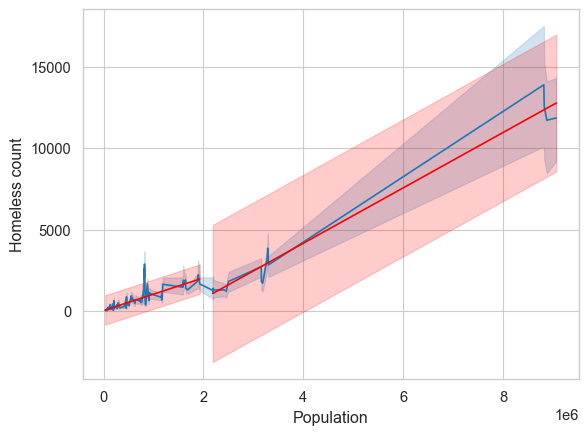

In [135]:
sns.lineplot(final_df, y="Homeless count", x="Population")
plt.xlabel("Population")
plt.ylabel("Homeless count")

pop_threshold = 2e6

sub_dfs = {
    f"Population < {pop_threshold}": final_df[final_df["Population"] < pop_threshold],
    f"Population ≥ {pop_threshold}": final_df[final_df["Population"] >= pop_threshold],
}

for label, sub_df in sub_dfs.items():
    slope, intercept, r_value, p_value, std_err = stats.linregress(sub_df["Population"], sub_df["Homeless count"])

    Y_pred = slope * sub_df["Population"] + intercept
    residuals = sub_df["Homeless count"] - Y_pred
    se = np.sqrt(np.sum(residuals**2) / (len(sub_df["Population"]) - 2)) 

    min, max = sub_df["Population"].min(), sub_df["Population"].max()
    plt.plot([min, max], [intercept + slope * min, intercept + slope * max], 'r')
    plt.fill_between(
        [min, max],
        [intercept + slope * min + 2*se, intercept + slope * max + 2*se],
        [intercept + slope * min - 2*se, intercept + slope * max - 2*se],
        color='red',
        alpha=0.2,
    )

In [137]:
sub_dfs[f"Population ≥ {pop_threshold}"].CoC_Name.unique()

array(['Los Angeles', 'San Diego', 'Orange', 'Riverside',
       'San Bernardino'], dtype=object)

In [139]:
for label, sub_df in sub_dfs.items():
    model = LinearRegression()
    model.fit(X_scaled[sub_df.index.to_numpy()], sub_df["Homeless count"])
    Y_pred = model.predict(X_scaled[sub_df.index.to_numpy()])

    rmse = np.sqrt(mean_squared_error(sub_df["Homeless count"], Y_pred))
    r2 = r2_score(sub_df["Homeless count"], Y_pred)

    print(f"# {label}")
    print(f"Training RMSE: {rmse:.2f}")
    print(f"Training R^2 Score: {r2:.2f}")

# Population < 2000000.0
Training RMSE: 445.73
Training R^2 Score: 0.52
# Population ≥ 2000000.0
Training RMSE: 1910.80
Training R^2 Score: 0.84


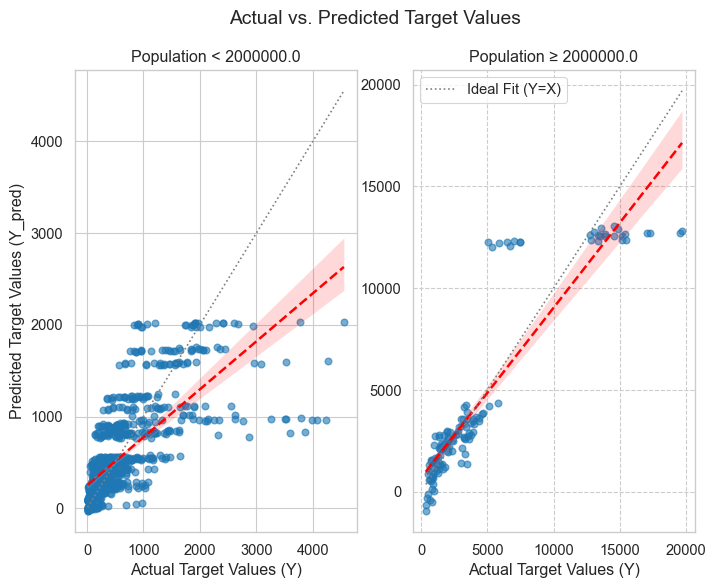

In [141]:
plt.figure(figsize=(8, 6))
for i, (label, sub_df) in enumerate(sub_dfs.items()):
    model = LinearRegression()
    model.fit(X_scaled[sub_df.index.to_numpy()], sub_df["Homeless count"])
    Y_pred = model.predict(X_scaled[sub_df.index.to_numpy()])

    plt.subplot(1, 2, i+1)
    sns.regplot(x=sub_df["Homeless count"], y=Y_pred, scatter_kws={'alpha':0.6}, line_kws={'color':'red', 'linestyle':'--'})
    min, max = sub_df["Homeless count"].min(), sub_df["Homeless count"].max()
    plt.plot([min, max], [min, max], color='gray', linestyle=':', label='Ideal Fit (Y=X)') # Ideal 45-degree line

    plt.xlabel("Actual Target Values (Y)")
    plt.ylabel("Predicted Target Values (Y_pred)")
    plt.title(label)
plt.ylabel(None)
plt.suptitle("Actual vs. Predicted Target Values")
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

/Users/imene/src/homelessness/venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/imene/src/homelessness/venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/imene/src/homelessness/venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


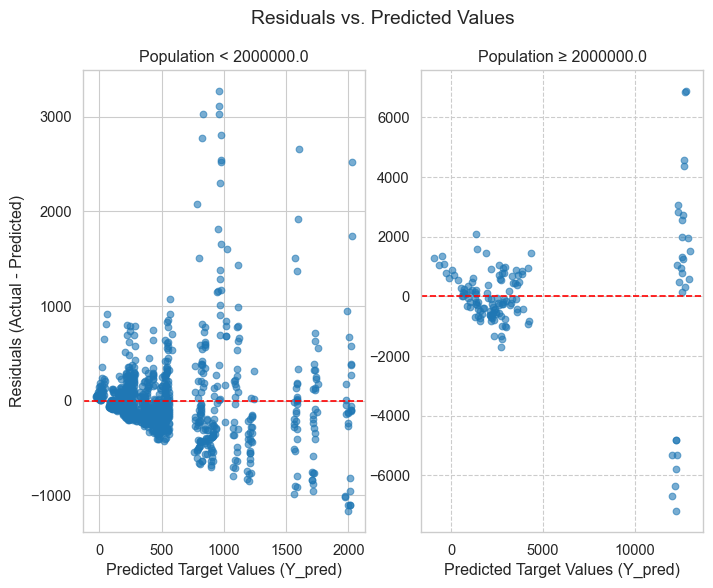

In [97]:
plt.figure(figsize=(8, 6))
for i, (label, sub_df) in enumerate(sub_dfs.items()):
    model = LinearRegression()
    model.fit(X_scaled[sub_df.index.to_numpy()], sub_df["Homeless count"])
    Y_pred = model.predict(X_scaled[sub_df.index.to_numpy()])

    plt.subplot(1, 2, i+1)
    residuals = sub_df["Homeless count"] - Y_pred

    plt.scatter(Y_pred, residuals, alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--') # Horizontal line at zero
    plt.xlabel("Predicted Target Values (Y_pred)")
    plt.ylabel("Residuals (Actual - Predicted)")
    plt.title(label)
plt.ylabel(None)
plt.suptitle("Residuals vs. Predicted Values")
plt.grid(True, linestyle='--')
plt.show()

/Users/imene/src/homelessness/venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/imene/src/homelessness/venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/imene/src/homelessness/venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


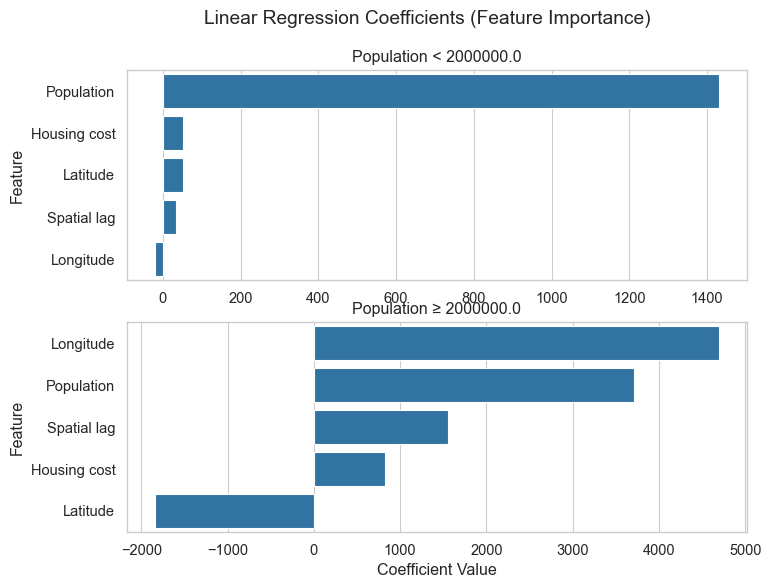

In [98]:
plt.figure(figsize=(8, 6))
for i, (label, sub_df) in enumerate(sub_dfs.items()):
    model = LinearRegression()
    model.fit(X_scaled[sub_df.index.to_numpy()], sub_df["Homeless count"])
    Y_pred = model.predict(X_scaled[sub_df.index.to_numpy()])

    plt.subplot(2, 1, i+1)
    coefficients_df = pd.DataFrame({'Feature': FEATURES, 'Coefficient': model.coef_})
    coefficients_df = coefficients_df.sort_values(by='Coefficient', ascending=False)

    sns.barplot(x='Coefficient', y='Feature', data=coefficients_df)
    plt.xlabel("Coefficient Value" if i > 0 else None)
    plt.ylabel("Feature")
    plt.title(label)
plt.suptitle("Linear Regression Coefficients (Feature Importance)")
plt.show()

/Users/imene/src/homelessness/venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/imene/src/homelessness/venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/imene/src/homelessness/venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


<Figure size 600x600 with 0 Axes>

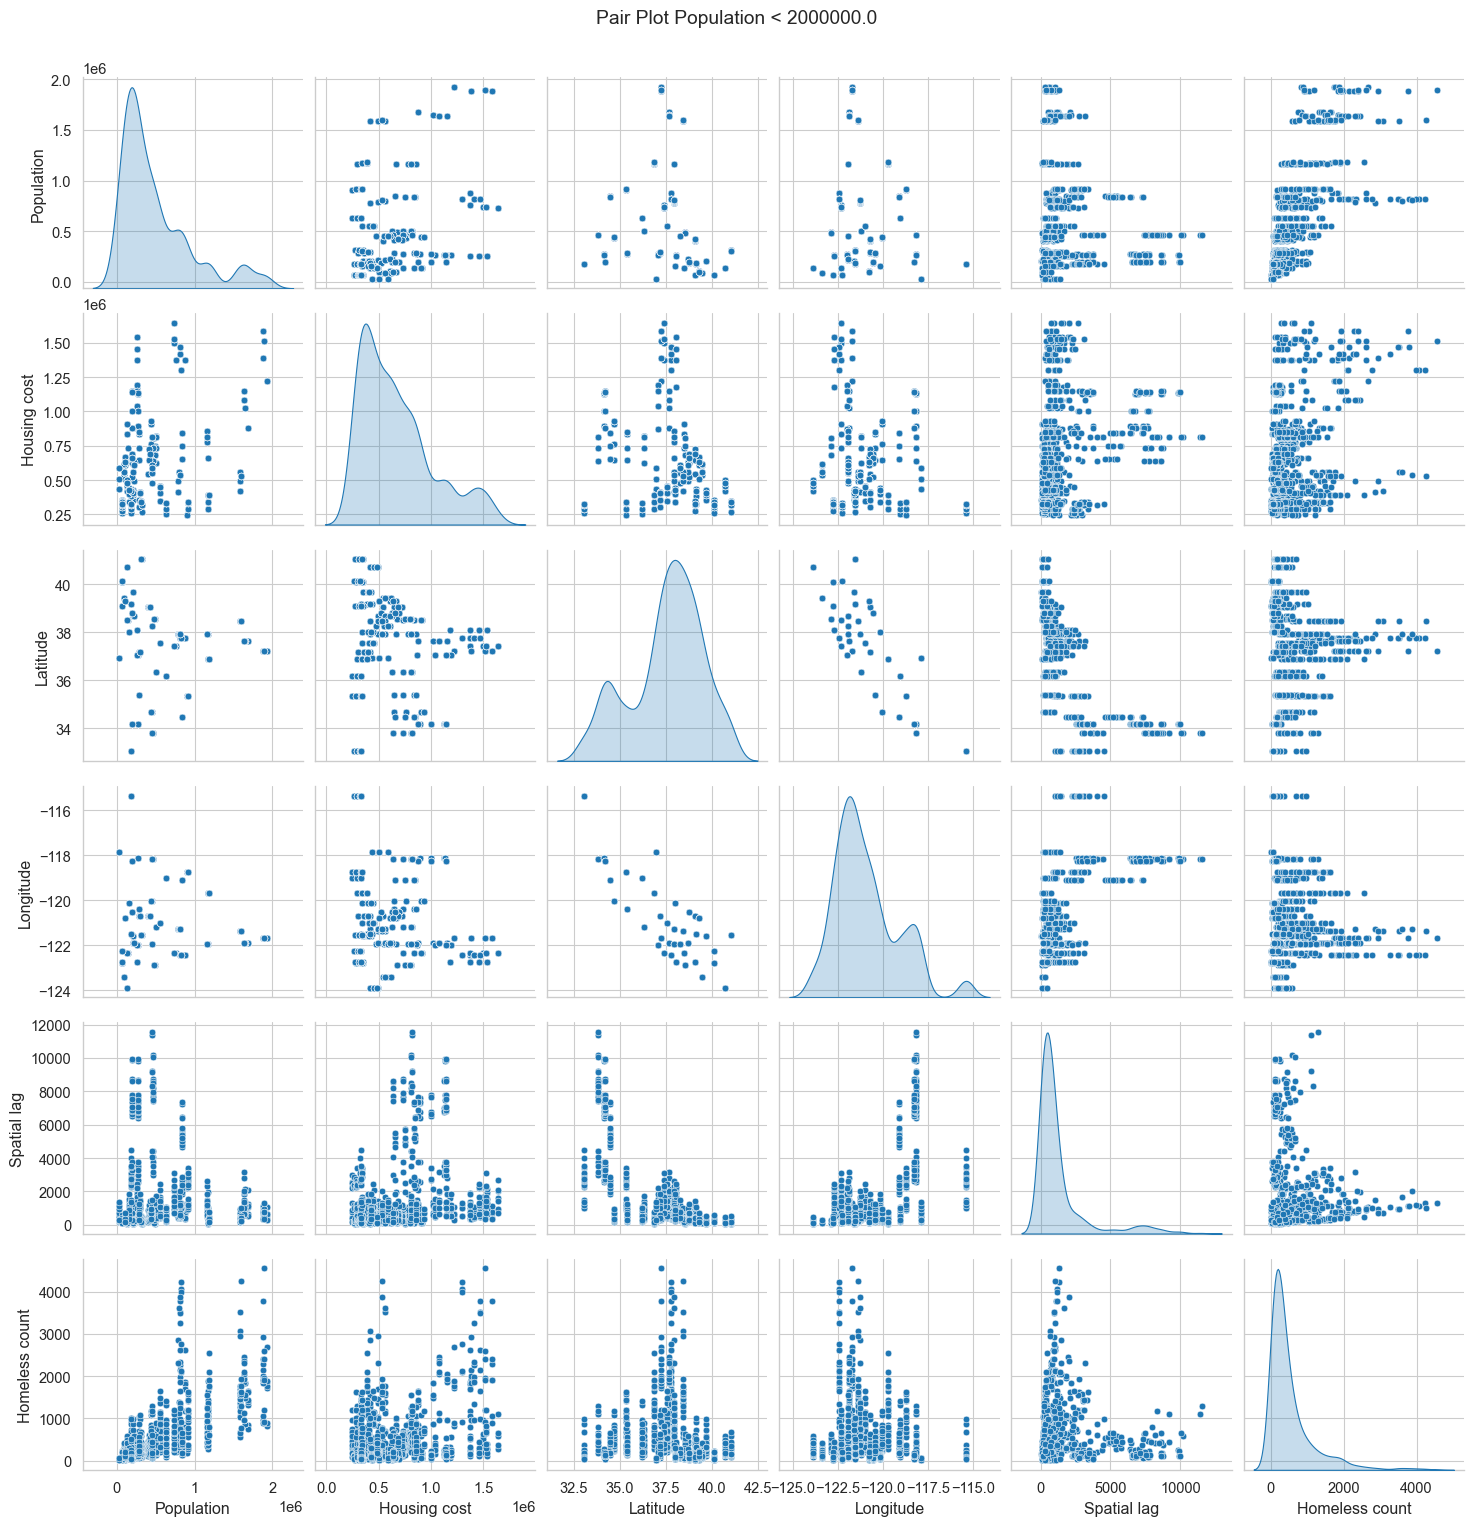

<Figure size 600x600 with 0 Axes>

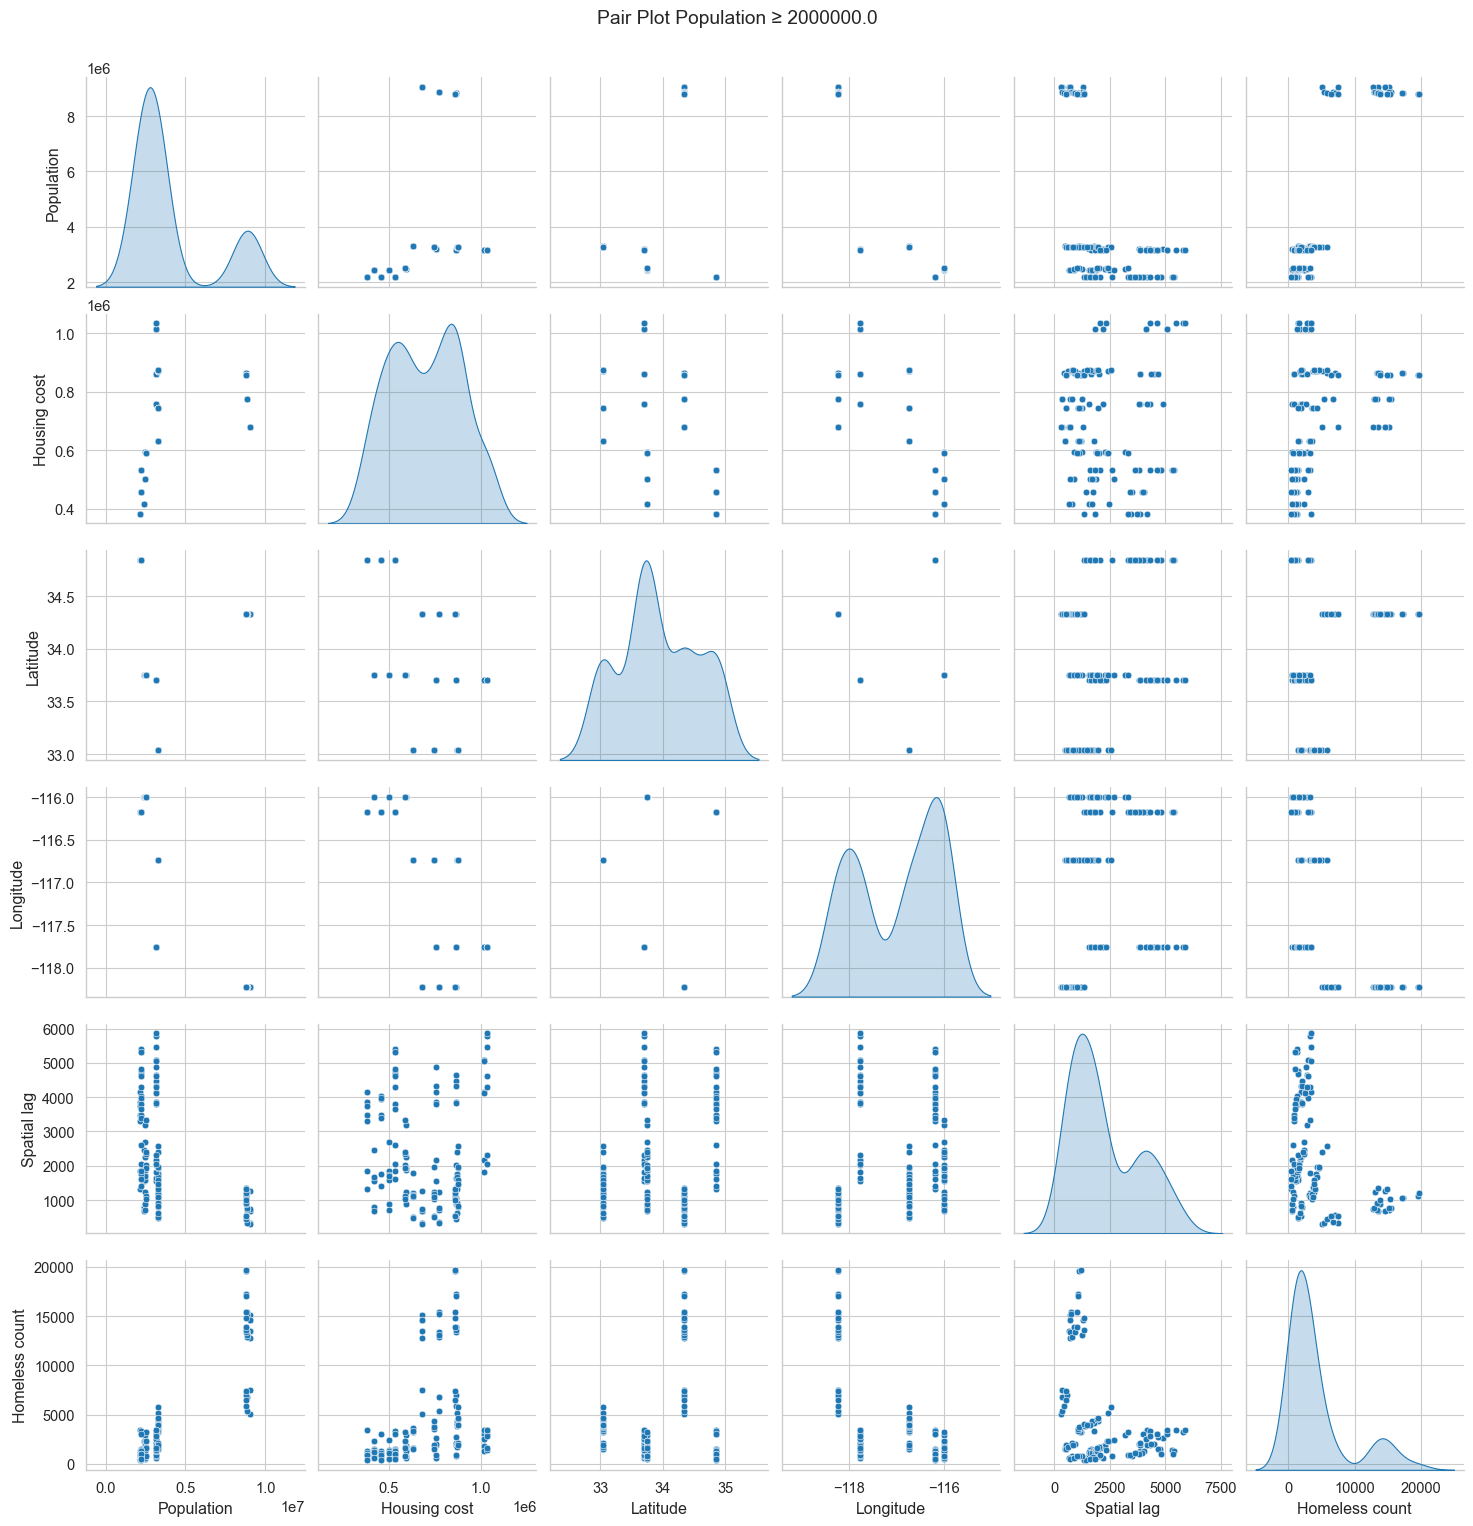

In [99]:
for i, (label, sub_df) in enumerate(sub_dfs.items()):
    model = LinearRegression()
    model.fit(X_scaled[sub_df.index.to_numpy()], sub_df["Homeless count"])
    Y_pred = model.predict(X_scaled[sub_df.index.to_numpy()])

    plt.figure(figsize=(6, 6))
    selected_cols = FEATURES + ['Homeless count']
    sns.pairplot(sub_df[selected_cols], diag_kind='kde') # 'kde' for density plot on diagonal
    plt.suptitle(f"Pair Plot {label}", y=1.02) # Adjust title position
    plt.show()

### 6.1 Feature Combination Analysis

In [ ]:
X = pd.get_dummies(final_df[["Year", "Age"] + ALL_FEATURES], columns=['Age'], prefix='Age')

In [ ]:
rmse_results = {}
score_results = {}
for i in range(1, len(FEATURES) + 1):
    for combo in combinations(FEATURES, i):
        combo_list = list(combo)
        X_combo = X[combo_list+['Year']+[f'Age_{group}' for group in final_df.Age.unique()]]
        
        num_experiments = 20
        total_rmse = 0
        total_score = 0
        for i in range(num_experiments):
            X_train, X_test, y_train, y_test = train_test_split(X_combo, y, test_size=0.2, random_state=i)
            
            model = RandomForestRegressor(n_estimators=100, random_state=i)#, oob_score=True)
            model.fit(X_train, y_train)

            preds = model.predict(X_test)
            total_rmse += np.sqrt(mean_squared_error(y_test, preds))
            total_score += model.score(X_test, y_test)

        rmse = total_rmse / num_experiments
        score = total_score / num_experiments
        rmse_results[combo] = rmse
        score_results[combo] = score

In [ ]:
# Plotting RMSE results
plt.figure(figsize=(12, 8))
sorted_results = sorted(rmse_results.items(), key=lambda item: item[1], reverse=True)
combo_labels = [' + '.join(c) for c, _ in sorted_results]
rmse_values = [r for _, r in sorted_results]
plt.barh(combo_labels, rmse_values, color='skyblue')
# plt.xlim((300, 400))
# plt.xscale('log')
plt.ylim((-1, len(rmse_values)))
# plt.text(360, 0, f"Outlier: {rmse_results[('Spatial lag',)]:.1f}", va='center', ha='right', fontsize=9)
plt.xlabel('Root Mean Squared Error (RMSE)')
plt.ylabel('Feature combination')
plt.title('Random Forest performance by feature combination')
plt.tight_layout()
plt.savefig("RF_RMSE_Features.pdf", dpi=300)
plt.show()

In [ ]:
# Plotting R^2 results
plt.figure(figsize=(12, 8))
sorted_results = sorted(score_results.items(), key=lambda item: item[1])
combo_labels = [' + '.join(c) for c, _ in sorted_results]
score_values = [r for _, r in sorted_results]
plt.barh(combo_labels, score_values, color='skyblue')
# plt.xlim((0.97, 0.98))
plt.ylim((-1, len(score_values)))
# plt.text(350, 0, f"Outlier: {score_results[('Spatial lag',)]:.1f}", va='center', ha='right', fontsize=9)
plt.xlabel('Proportion of variance explained (R²)')
plt.ylabel('Feature combination')
plt.title('Random Forest performance by feature combination')
plt.tight_layout()
plt.show()

In [ ]:
ancova_rmse_results = {}
ancova_score_results = {}
for group in FEATURE_GROUPS:
    print(group)
    for i in range(1, len(group) + 1):
        for combo in combinations(group, i):
            combo_list = list(combo)
            X_combo = final_df[combo_list + ["Year", "Age"]]

            num_experiments = 20
            total_rmse = 0
            total_score = 0
            for j in range(num_experiments):
                X_train, X_test, y_train, y_test = train_test_split(
                    X_combo, y, test_size=0.2, random_state=i + 100 * j
                )

                formula = f'Q("Homeless count") ~ Year + C(Age) + {' + '.join([f'Q("{feature}")' for feature in combo])}'
                model = smf.ols(formula, data=final_df).fit()

                preds = model.predict(X_test)
                total_rmse += np.sqrt(mean_squared_error(y_test, preds))
                total_score += model.rsquared

            rmse = total_rmse / num_experiments
            score = total_score / num_experiments
            ancova_rmse_results[(combo,())] = rmse
            ancova_score_results[(combo,())] = score

            if len(combo) > 1:
                for cross in combinations(combo, 2):
                    num_experiments = 20
                    total_rmse = 0
                    total_score = 0
                    for j in range(num_experiments):
                        X_train, X_test, y_train, y_test = train_test_split(
                            X_combo, y, test_size=0.2, random_state=i + 100 * j
                        )

                        formula = f'Q("Homeless count") ~ Year + C(Age) + {
                            ' + '.join([f'Q("{feature}")' for feature in combo])
                        } + {' : '.join([f'Q("{feature}")' for feature in cross])}'
                        model = smf.ols(formula, data=final_df).fit()

                        preds = model.predict(X_test)
                        total_rmse += np.sqrt(mean_squared_error(y_test, preds))
                        total_score += model.rsquared

                    rmse = total_rmse / num_experiments
                    score = total_score / num_experiments
                    ancova_rmse_results[(combo, cross)] = rmse
                    ancova_score_results[(combo, cross)] = score

In [ ]:
# Plotting ANCOVA RMSE results
plt.figure(figsize=(12, 200))
sorted_results = sorted(ancova_rmse_results.items(), key=lambda item: item[1], reverse=True)
combo_labels = [f"{' + '.join(combo)} + {' * '.join(cross)}" if len(cross) > 0 else ' + '.join(combo) for (combo, cross), _ in sorted_results]
rmse_values = [r for _, r in sorted_results]
plt.barh(combo_labels, rmse_values, color='skyblue')
plt.ylim([-1, len(rmse_values)])
plt.xlabel('Root Mean Squared Error (RMSE)')
plt.ylabel('Feature combination')
plt.title('ANCOVA (OLS) performance by feature combination')
plt.tight_layout()
plt.show()

In [ ]:
# Plotting ANCOVA R^2 results
plt.figure(figsize=(12, 200))
sorted_results = sorted(ancova_score_results.items(), key=lambda item: item[1])
combo_labels = [f"{' + '.join(combo)} + {' * '.join(cross)}" if len(cross) > 0 else ' + '.join(combo) for (combo, cross), _ in sorted_results]
score_values = [r for _, r in sorted_results]
plt.barh(combo_labels, score_values, color='skyblue')
plt.ylim([-1, len(rmse_values)])
plt.xlabel('Proportion of variance explained (R²)')
plt.ylabel('Feature combination')
plt.title('ANCOVA (OLS) performance by feature combination')
plt.tight_layout()
plt.show()

In [ ]:
# Plotting ANCOVA RMSE results
plt.figure(figsize=(12, 12))
sorted_results = sorted(
    ancova_rmse_results.items(), key=lambda item: item[1], reverse=True
)
sorted_results = list(
    filter(
        lambda item: ("Latitude" in item[0][1] and "Longitude" in item[0][1])
        or ("Latitude" in item[0][0] and len(item[0][0]) == 1)
        or ("Longitude" in item[0][0] and len(item[0][0]) == 1)
        or ("Latitude" in item[0][0] and "Longitude" in item[0][0] and len(item[0][0]) == 2),
        sorted_results,
    )
)
combo_labels = [
    f"{' + '.join(combo)} + {' * '.join(cross)}" if len(cross) > 0 else ' + '.join(combo) for (combo, cross), _ in sorted_results
]
rmse_values = [r for _, r in sorted_results]
plt.barh(combo_labels, rmse_values, color="skyblue")
plt.xlabel("Root Mean Squared Error (RMSE)")
plt.ylabel("Feature combination")
plt.title("ANCOVA (OLS) performance by feature combination (zoom on lat/long)")
plt.tight_layout()
plt.show()

### 6.2 Model Comparison: ANCOVA vs. Random Forest

In [ ]:
# ANCOVA (OLS Linear Model)
num_experiments = 100
total_rmse = 0
for i in range(num_experiments):
    X_train, X_test, y_train, y_test = train_test_split(final_df[["Year", "Age"] + FEATURES], y, test_size=0.2, random_state=i)
    formula = f'Q("Homeless count") ~ Year + C(Age) + {' + '.join([f'Q("{feature}")' for feature in FEATURES])}'
    # X_train, X_test, y_train, y_test = train_test_split(final_df[["Year", "Age", "Population", "square(Housing cost)", "Spatial lag"]], y, test_size=0.2, random_state=i)
    # formula = f'Q("Homeless count") ~ Year + C(Age) + Population + Q("square(Housing cost)") * Q("Spatial lag")'
    ols_model = smf.ols(formula, data=final_df).fit()
    ols_preds = ols_model.predict(X_test)
    total_rmse += np.sqrt(mean_squared_error(y_test, ols_preds))
ols_rmse = total_rmse / num_experiments
print(f"\nANCOVA (OLS) Model RMSE: {ols_rmse:.2f}")
print(ols_model.summary())

In [ ]:
final_df2 = final_df[["Year", "Age"] + FEATURES]
# final_df2 = final_df[["Year", "Age"] + [f"normalized({feat})" for feat in FEATURES]]
final_df2["Homeless count"] = y.copy()
final_df2 = final_df2.groupby(["Year", "Age"] + FEATURES, observed=True)['Homeless count'].sum().reset_index()
# final_df2 = final_df2.groupby(["Year", "Age"] + [f"normalized({feat})" for feat in FEATURES], observed=True)['Homeless count'].sum().reset_index()
X_test = final_df2.drop(columns="Homeless count")
formula = f'Q("Homeless count") ~ Year + C(Age) + {' + '.join([f'Q("{feature}")' for feature in FEATURES])}'
# formula = f'Q("Homeless count") ~ Year + C(Age) + {' + '.join([f'Q("normalized({feature})")' for feature in FEATURES])}'
ols_model = smf.ols(formula, data=final_df2).fit()
final_df2["Pred"] = ols_model.predict(X_test)
print(ols_model.summary())

In [ ]:
# sns.lineplot(final_df2, x="Year", y="Homeless count")
# sns.lineplot(final_df2, x="Year", y="Pred")
sns.lineplot(final_df2[final_df2.Age=="65+"], x="Year", y="Homeless count")
sns.lineplot(final_df2[final_df2.Age=="65+"], x="Year", y="Pred")
plt.legend(["Predicted (mean)", "Predicted (95% CI)", "Actual (mean)", "Actual (95% CI)"])
plt.xticks(final_df2.Year.unique())
plt.show()

In [ ]:
# sns.lineplot(final_df2, x="Population", y="Homeless count")
# sns.lineplot(final_df2, x="Population", y="Pred")
sns.lineplot(final_df2[final_df2.Age=="65+"], x="Population", y="Homeless count")
sns.lineplot(final_df2[final_df2.Age=="65+"], x="Population", y="Pred")
plt.legend(["Predicted (mean)", "Predicted (95% CI)", "Actual (mean)", "Actual (95% CI)"])
plt.show()

In [ ]:
sns.lineplot(final_df2[final_df2.Age=="65+"], x="Spatial lag", y="Homeless count")
sns.lineplot(final_df2[final_df2.Age=="65+"], x="Spatial lag", y="Pred")
plt.legend(["Predicted (mean)", "Predicted (95% CI)", "Actual (mean)", "Actual (95% CI)"])
plt.show()

In [ ]:
sns.lineplot(final_df2[final_df2.Age=="65+"], x="Housing cost", y="Homeless count")
sns.lineplot(final_df2[final_df2.Age=="65+"], x="Housing cost", y="Pred")
plt.legend(["Predicted (mean)", "Predicted (95% CI)", "Actual (mean)", "Actual (95% CI)"])
plt.show()

In [ ]:
sns.lineplot(final_df2[final_df2.Age=="65+"], x="Latitude", y="Homeless count")
sns.lineplot(final_df2[final_df2.Age=="65+"], x="Latitude", y="Pred")
plt.legend(["Predicted (mean)", "Predicted (95% CI)", "Actual (mean)", "Actual (95% CI)"])
plt.show()

In [ ]:
sns.lineplot(final_df2[final_df2.Age=="65+"], x="Longitude", y="Homeless count")
sns.lineplot(final_df2[final_df2.Age=="65+"], x="Longitude", y="Pred")
plt.legend(["Predicted (mean)", "Predicted (95% CI)", "Actual (mean)", "Actual (95% CI)"])
plt.show()

In [ ]:
final_df3 = final_df[["Year", "Age"] + FEATURES]
final_df3["Homeless count"] = y.copy()
final_df3 = final_df3.groupby(["Year", "Age"] + FEATURES, observed=True)['Homeless count'].sum().reset_index()
final_df3 = final_df3[final_df3.Age == "65+"]
X_test = final_df3.drop(columns=["Homeless count", "Age"])
rf_model = RandomForestRegressor(n_estimators=100, random_state=i)
rf_model.fit(X[["Year"]+FEATURES], y)
final_df3["Pred"] = rf_model.predict(X_test)

In [ ]:
sns.lineplot(final_df2[final_df2.Age=="65+"], x="Year", y="Homeless count")
sns.lineplot(final_df2[final_df2.Age=="65+"], x="Year", y="Pred")
sns.lineplot(final_df3, x="Year", y="Pred")
plt.legend(["Actual (mean)", "Actual (95% CI)", "Predicted (mean)", "Predicted (95% CI)", "Predicted RF (mean)", "Predicted RF (95% CI)"])
plt.xticks(final_df2.Year.unique())
plt.show()

In [ ]:
sns.lineplot(final_df2[final_df2.Age=="65+"], x="Population", y="Homeless count")
sns.lineplot(final_df2[final_df2.Age=="65+"], x="Population", y="Pred")
sns.lineplot(final_df3, x="Population", y="Pred")
plt.legend(["Actual (mean)", "Actual (95% CI)", "Predicted ANCOVA (mean)", "Predicted ANCOVA (95% CI)", "Predicted RF (mean)", "Predicted RF (95% CI)"])
plt.show()

In [ ]:
sns.lineplot(final_df2[final_df2.Age=="65+"], x="Spatial lag", y="Homeless count")
sns.lineplot(final_df2[final_df2.Age=="65+"], x="Spatial lag", y="Pred")
sns.lineplot(final_df3, x="Spatial lag", y="Pred")
plt.legend(["Actual (mean)", "Actual (95% CI)", "Predicted ANCOVA (mean)", "Predicted ANCOVA (95% CI)", "Predicted RF (mean)", "Predicted RF (95% CI)"])
plt.show()

In [ ]:
sns.lineplot(final_df2[final_df2.Age=="65+"], x="Housing cost", y="Homeless count")
sns.lineplot(final_df2[final_df2.Age=="65+"], x="Housing cost", y="Pred")
sns.lineplot(final_df3, x="Housing cost", y="Pred")
plt.legend(["Actual (mean)", "Actual (95% CI)", "Predicted ANCOVA (mean)", "Predicted ANCOVA (95% CI)", "Predicted RF (mean)", "Predicted RF (95% CI)"])
plt.show()

In [ ]:
sns.lineplot(final_df2[final_df2.Age=="65+"], x="Latitude", y="Homeless count")
sns.lineplot(final_df2[final_df2.Age=="65+"], x="Latitude", y="Pred")
sns.lineplot(final_df3, x="Latitude", y="Pred")
plt.legend(["Actual (mean)", "Actual (95% CI)", "Predicted ANCOVA (mean)", "Predicted ANCOVA (95% CI)", "Predicted RF (mean)", "Predicted RF (95% CI)"])
plt.show()

In [ ]:
sns.lineplot(final_df2[final_df2.Age=="65+"], x="Longitude", y="Homeless count")
sns.lineplot(final_df2[final_df2.Age=="65+"], x="Longitude", y="Pred")
sns.lineplot(final_df3, x="Longitude", y="Pred")
plt.legend(["Actual (mean)", "Actual (95% CI)", "Predicted ANCOVA (mean)", "Predicted ANCOVA (95% CI)", "Predicted RF (mean)", "Predicted RF (95% CI)"])
plt.show()

In [ ]:
g = sns.pairplot(final_df[["Age"]+FEATURES], hue="Age")
g.map_lower(sns.kdeplot, levels=4, color=".2")

In [ ]:
df_pivoted = final_df[["CoC_Name", "Year", "Age", "Homeless count"]].pivot(index=["CoC_Name", "Year"], columns='Age', values='Homeless count')
df_pivoted = df_pivoted.reset_index()

In [ ]:
g = sns.pairplot(df_pivoted[[col for col in df_pivoted.columns if col not in ["CoC_Name", "Year"]]])
g.map_lower(sns.kdeplot, levels=4, color=".2")

In [ ]:
# Random Forest
num_experiments = 100
total_rmse = 0
gini_importances = []
perm_importances = []
for i in range(num_experiments):
    X_train, X_test, y_train, y_test = train_test_split(X[FEATURES], y, test_size=0.2, random_state=i)
    rf_model = RandomForestRegressor(n_estimators=100, random_state=i)
    rf_model.fit(X_train, y_train)
    gini_importances.append(rf_model.feature_importances_)
    perm_imp_result = permutation_importance(rf_model, X_test, y_test, n_repeats=10, random_state=i, scoring='neg_root_mean_squared_error')
    perm_importances.append(perm_imp_result.importances_mean)
    rf_preds = rf_model.predict(X_test)
    total_rmse += np.sqrt(mean_squared_error(y_test, rf_preds))
rf_rmse = total_rmse / num_experiments
avg_gini_importance = np.mean(gini_importances, axis=0)
avg_perm_importance = np.mean(perm_importances, axis=0)
feature_importance_df = pd.DataFrame({
    'Feature': FEATURES,
    'Average Gini importance': avg_gini_importance,
    'Average permutation importance': avg_perm_importance
})
feature_importance_df = feature_importance_df.sort_values(by='Average permutation importance', ascending=False)

print("Average RMSE:", rf_rmse)
print("Feature importance DataFrame:")
print(feature_importance_df)

In [ ]:
# Untrained model
num_experiments = 100
total_rmse_bad = 0
for i in range(num_experiments):
    X_train, X_test, y_train, y_test = train_test_split(X[FEATURES], y, test_size=0.2, random_state=i)
    rf_model_bad = RandomForestRegressor(n_estimators=100, random_state=i)
    rf_model_bad.fit(X_train.head(1), y_train.head(1))
    rf_preds_bad = rf_model_bad.predict(X_test)
    total_rmse_bad += np.sqrt(mean_squared_error(y_test, rf_preds_bad))
rf_rmse_bad = total_rmse_bad / num_experiments
print(f"Untrained Random Forest Model RMSE: {rf_rmse_bad:.2f}")

In [ ]:
# Comparison Plot
plt.figure(figsize=(8, 6))
model_names = ['Untrained', 'ANCOVA (OLS)', 'Random Forest']
rmse_scores = [rf_rmse_bad, ols_rmse, rf_rmse]
sns.barplot(x=model_names, y=rmse_scores)
plt.ylabel('Root Mean Squared Error (RMSE)')
plt.title('Model comparison: predictive accuracy')
plt.show()

## 7. Final Model Analysis and Visualization

In [ ]:
# --- Predicted vs. Actual Plot ---
plt.figure(figsize=(8, 8))
plt.scatter(y_test, rf_preds, alpha=0.6, edgecolors='k', c='royalblue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--', color='red', lw=2)
plt.xlabel('Actual homeless count (65+)')
plt.ylabel('Predicted homeless count (65+)')
plt.title('Random Forest: predicted vs. actual values')
plt.grid(True)
plt.show()

In [ ]:
# --- Feature Importance Plot (GINI) ---
plt.figure(figsize=(10, 6))
sns.barplot(feature_importance_df, x='Average Gini importance', y='Feature', hue='Average Gini importance', legend=False, palette='viridis_r')
plt.xscale('log')
plt.title('Random Forest feature importances')
plt.savefig("rf_gini.pdf", dpi=300)
plt.show()

In [ ]:
# --- Feature Importance Plot (permutation) ---
plt.figure(figsize=(10, 6))
sns.barplot(feature_importance_df, x='Average permutation importance', y='Feature', hue='Average permutation importance', legend=False, palette='viridis_r')
plt.xscale('log')
plt.title('Random Forest permutation-based feature importances')
plt.savefig("rf_feature_importance.pdf", dpi=300)
plt.show()

## 8. Prediction Set with averaged features

In [ ]:
# This section creates a synthetic dataset where features (population, spatial lag, housing cost, etc.)
# of every CoC is set to the statewide average. This allows us to predict homelessness
# counts based on factors other than those features (e.g. policy).

# Create a copy of the final dataframe for our prediction set
prediction_set_df = pd.get_dummies(final_df, columns=['Age'], prefix='Age').set_index('CoC_Name').drop(columns='Homeless count')

# Calculate the average population
avg_population = prediction_set_df['Population'].unique().mean()
print(f"Using an average population of {avg_population:,.0f} for all CoCs.")

# Calculate the average spatial lag
avg_spatial_lag = prediction_set_df['Spatial lag'].unique().mean()
print(f"Using an average spatial lag of {avg_spatial_lag:,.0f} for all CoCs.")

# Calculate the average housing cost
avg_housing_cost = prediction_set_df['Housing cost'].unique().mean()
print(f"Using an average housing cost of {avg_housing_cost:,.2f} for all CoCs.")

# Calculate the average latitude
avg_latitude = prediction_set_df['Latitude'].unique().mean()
print(f"Using an average latitude of {avg_latitude:,.3f} for all CoCs.")

# Calculate the average longitude
avg_longitude = prediction_set_df['Longitude'].unique().mean()
print(f"Using an average longitude of {avg_longitude:,.3f} for all CoCs.")

# Replace the population features with the average values
prediction_set_df['Population'] = avg_population
prediction_set_df['Spatial lag'] = avg_spatial_lag
prediction_set_df['Housing cost'] = avg_housing_cost
# prediction_set_df['Latitude'] = avg_latitude
# prediction_set_df['Longitude'] = avg_longitude

# Select the same features the model was trained on
# X_prediction = prediction_set_df[FEATURES]
X_prediction = prediction_set_df.drop(columns=[f"normalized({feature})" for feature in FEATURES])

# for group in final_df.Age.unique():
#     X_prediction[f'Age_{group}'] = X[f'Age_{group}']
# X_prediction['Year'] = X['Year']
# X_prediction['Homeless count'] = X['Homeless count']
# X_prediction['Age_Invalid'] = X['Age_Invalid']
# X_prediction['Age_Unknown'] = X['Age_Unknown']

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X[[col for col in X.columns if '(' not in col]], y)

# Use the trained Random Forest model to predict on this new dataset
prediction_set_preds = rf_model.predict(X_prediction[[col for col in X_prediction.columns if '(' not in col]])

# Add predictions to the dataframe
prediction_set_df['Predicted_Homeless_Avg_Pop'] = prediction_set_preds

Visualize the Prediction Set Results

In [ ]:
# Sort for better visualization
sorted_predictions = prediction_set_df[(prediction_set_df.Year == 2023) & (prediction_set_df['Age_65+'])].sort_values('Predicted_Homeless_Avg_Pop', ascending=False)
# sorted_predictions = prediction_set_df[(prediction_set_df['Age_65+'])].sort_values('Predicted_Homeless_Avg_Pop', ascending=False)
# sorted_predictions = prediction_set_df[(prediction_set_df.Year == 2023)].sort_values('Predicted_Homeless_Avg_Pop', ascending=False)
# sorted_predictions = prediction_set_df.sort_values('Predicted_Homeless_Avg_Pop', ascending=False)

plt.figure(figsize=(12, 10))
sns.barplot(x='Predicted_Homeless_Avg_Pop', y=sorted_predictions.index, data=sorted_predictions, palette='coolwarm_r', hue=sorted_predictions.index, dodge=False, legend=False)
plt.xlabel('Predicted homeless count with average population')
plt.ylabel('Continuum of Care (CoC)')
plt.title('Predicted homelessness (65+) if all CoCs had average population and housing cost')
plt.tight_layout()
plt.savefig("predicted_chart.pdf", dpi=300)
plt.show()

#### Now with ANCOVA

In [ ]:
# This section creates a synthetic dataset where features (population, spatial lag, housing cost, etc.)
# of every CoC is set to the statewide average. This allows us to predict homelessness
# counts based on factors other than those features (e.g. policy).

# Create a copy of the final dataframe for our prediction set
prediction_set_df = pd.get_dummies(final_df, columns=['Age'], prefix='Age').set_index('CoC_Name').drop(columns='Homeless count')

# Calculate the average population
avg_population = prediction_set_df['Population'].unique().mean()
print(f"Using an average population of {avg_population:,.0f} for all CoCs.")

# Calculate the average spatial lag
avg_spatial_lag = prediction_set_df['Spatial lag'].unique().mean()
print(f"Using an average spatial lag of {avg_spatial_lag:,.0f} for all CoCs.")

# Calculate the average housing cost
avg_housing_cost = prediction_set_df['Housing cost'].unique().mean()
print(f"Using an average housing cost of {avg_housing_cost:,.2f} for all CoCs.")

# Calculate the average latitude
avg_latitude = prediction_set_df['Latitude'].unique().mean()
print(f"Using an average latitude of {avg_latitude:,.3f} for all CoCs.")

# Calculate the average longitude
avg_longitude = prediction_set_df['Longitude'].unique().mean()
print(f"Using an average longitude of {avg_longitude:,.3f} for all CoCs.")

# Replace the population features with the average values
prediction_set_df['Population'] = avg_population
prediction_set_df['Spatial lag'] = avg_spatial_lag
prediction_set_df['Housing cost'] = avg_housing_cost
# prediction_set_df['Latitude'] = avg_latitude
# prediction_set_df['Longitude'] = avg_longitude

# Select the same features the model was trained on
# X_prediction = prediction_set_df[FEATURES]
X_prediction = prediction_set_df.drop(columns=[f"normalized({feature})" for feature in FEATURES])

# for group in final_df.Age.unique():
#     X_prediction[f'Age_{group}'] = X[f'Age_{group}']
# X_prediction['Year'] = X['Year']
# X_prediction['Homeless count'] = X['Homeless count']
# X_prediction['Age_Invalid'] = X['Age_Invalid']
# X_prediction['Age_Unknown'] = X['Age_Unknown']

# rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
# rf_model.fit(X[[col for col in X.columns if '(' not in col]], y)
# X_train, X_test, y_train, y_test = train_test_split(final_df[["Year", "Age"] + FEATURES], y, test_size=0.2, random_state=i)
formula = f'Q("Homeless count") ~ Year + {' + '.join([f'Q("{feature}")' for feature in FEATURES])}'
ols_model = smf.ols(formula, data=final_df).fit()

# Use the trained Random Forest model to predict on this new dataset
# prediction_set_preds = rf_model.predict(X_prediction[[col for col in X_prediction.columns if '(' not in col]])
prediction_set_preds = ols_model.predict(X_prediction[[col for col in X_prediction.columns if '(' not in col]])


# Add predictions to the dataframe
prediction_set_df['Predicted_Homeless_Avg_Pop'] = prediction_set_preds

In [ ]:
# Sort for better visualization
sorted_predictions = prediction_set_df[(prediction_set_df.Year == 2023) & (prediction_set_df['Age_65+'])].sort_values('Predicted_Homeless_Avg_Pop', ascending=False)
# sorted_predictions = prediction_set_df[(prediction_set_df['Age_65+'])].sort_values('Predicted_Homeless_Avg_Pop', ascending=False)
# sorted_predictions = prediction_set_df[(prediction_set_df.Year == 2023)].sort_values('Predicted_Homeless_Avg_Pop', ascending=False)
# sorted_predictions = prediction_set_df.sort_values('Predicted_Homeless_Avg_Pop', ascending=False)

plt.figure(figsize=(12, 10))
sns.barplot(x='Predicted_Homeless_Avg_Pop', y=sorted_predictions.index, data=sorted_predictions, palette='coolwarm_r', hue=sorted_predictions.index, dodge=False, legend=False)
plt.xlabel('Predicted homeless count with average population')
plt.ylabel('Continuum of Care (CoC)')
plt.title('Predicted homelessness (65+) if all CoCs had average population and housing cost')
plt.tight_layout()
plt.savefig("predicted_chart.pdf", dpi=300)
plt.show()

# Leave-one-out predictions

Say we don't know *anything* about a particular CoC. Given its input features, how would the model output compare to the actual unhoused population?

Repeat that for each CoC to get the full map.

In [ ]:
# Random Forest
pred_df = final_df.copy()
for CoC_Name in final_df.CoC_Name.unique():
    X_train = final_df[FEATURES][final_df.CoC_Name != CoC_Name]
    X_test = final_df[FEATURES][final_df.CoC_Name == CoC_Name]
    y_train = y[final_df.CoC_Name != CoC_Name]
    y_test = y[final_df.CoC_Name == CoC_Name]
    rf_model = RandomForestRegressor(n_estimators=100, random_state=i)
    rf_model.fit(X_train, y_train)
    pred_df.loc[X_test.index, "Pred"] = rf_model.predict(X_test)

# Map plotting

In [ ]:
def plot_metric_on_map(
    metric_df, coc_geodata, column_name, title, cmap="viridis", label=None, norm=None
):
    """
    Generates a choropleth map of a specified metric for California CoCs.

    Args:
        metric_df (pd.DataFrame): DataFrame containing the metric data with CoC names as index.
        coc_geodata (gpd.GeoDataFrame): GeoDataFrame with CoC geometries and a 'CoC_Name' column.
        column_name (str): The name of the column in metric_df to plot.
        title (str): The title for the map.
        cmap (str, optional): The colormap to use. Defaults to 'viridis'.
        label (str, optional): The label for the color bar. If None, uses column_name.
    """
    if label is None:
        label = column_name

    # Merge the metric data with the geospatial data
    map_data = coc_geodata.merge(
        metric_df[[column_name]],
        left_on="CoC_Name",
        right_index=True,
        how="inner",
    )

    # Create the plot
    fig, ax = plt.subplots(1, 1, figsize=(12, 12))
    map_data.plot(
        column=column_name,
        ax=ax,
        legend=True,
        cmap=cmap,
        legend_kwds={
            "label": label,
            "shrink": 0.8,
            # "orientation": "horizontal",
        },
        norm=norm,
    )

    ax.set_title(title, fontdict={"fontsize": "16", "fontweight": "3"})
    ax.set_axis_off()
    plt.show()
    return fig

In [ ]:
fig = plot_metric_on_map(
    final_df[(final_df.Year==2023)&(final_df.Age=='65+')].set_index('CoC_Name'),
    coc_gdf,
    column_name="Population",
    title="2023 population by CoC",
    norm=LogNorm(vmin=1e4, vmax=1e7),
)
fig.savefig("population.pdf", dpi=300)

In [ ]:
fig = plot_metric_on_map(
    final_df[(final_df.Year==2023)&(final_df.Age=='65+')].set_index('CoC_Name'),
    coc_gdf,
    column_name="Spatial lag",
    title="2023 spatial lag for 65+ by CoC",
    norm=LogNorm(),
)

In [ ]:
fig = plot_metric_on_map(
    final_df[(final_df.Year==2023)&(final_df.Age=='65+')].set_index('CoC_Name'),
    coc_gdf,
    column_name="Housing cost",
    title="2023 population-weighted ZHVI by CoC",
    label="Weighted Home Value Index",
    # norm=LogNorm(),
)
fig.savefig("housing_cost.pdf", dpi=300)

In [ ]:
fig = plot_metric_on_map(
    final_df[(final_df.Year==2023)&(final_df.Age=='65+')].set_index('CoC_Name'),
    coc_gdf,
    column_name="Homeless count",
    title="2023 homeless count (65+) by CoC",
    norm=LogNorm(),
)
fig.savefig("homeless_count.pdf", dpi=300)

In [ ]:
final_df2 = final_df.copy()
final_df2["Proportion of unhoused individuals"] = final_df["Homeless count"] / final_df["Population"]
fig = plot_metric_on_map(
    final_df2[(final_df.Year==2023)&(final_df.Age=='65+')].set_index('CoC_Name'),
    coc_gdf,
    column_name="Proportion of unhoused individuals",
    title="65+ unhoused proportion relative to total population size by CoC in 2023",
    norm=LogNorm(),
)
fig.savefig("unhoused_prop.pdf", dpi=300)

In [ ]:
final_df2 = final_df.copy()
final_df2["One"] = 1
fig = plot_metric_on_map(
    final_df2[(final_df.Year==2023)&(final_df.Age=='65+')].set_index('CoC_Name'),
    coc_gdf,
    column_name="One",
    title="California Continuums of Care in 2023",
    norm=LogNorm(),
)
fig.savefig("cocs.pdf", dpi=300)

In [ ]:
final_df2 = final_df.copy()
final_df2 = final_df2.groupby(['CoC_Name', 'Year'], observed=True)['Homeless count'].sum().reset_index()
fig = plot_metric_on_map(
    final_df2[(final_df2.Year==2023)].set_index('CoC_Name'),
    coc_gdf,
    column_name="Homeless count",
    label="Unhoused population size",
    title="Unhoused population size by CoC in 2023",
    norm=LogNorm(),
)
fig.savefig("unhoused_count.pdf", dpi=300)

In [ ]:
final_df2 = final_df.copy()
final_df2 = final_df2.groupby(['CoC_Name', 'Year', 'Population'], observed=True)['Homeless count'].sum().reset_index()
final_df2["Proportion of unhoused individuals"] = final_df2["Homeless count"] / final_df2["Population"]
fig = plot_metric_on_map(
    final_df2[(final_df2.Year==2023)].set_index('CoC_Name'),
    coc_gdf,
    column_name="Proportion of unhoused individuals",
    title="Proportion of unhoused individuals relative to total population size by CoC in 2023",
    norm=LogNorm(),
)
fig.savefig("unhoused_prop.pdf", dpi=300)

In [ ]:
fig = plot_metric_on_map(
    pred_df[(final_df.Year==2023)&(final_df.Age=='65+')].set_index('CoC_Name'),
    coc_gdf,
    column_name="Homeless count",
    label="Unhoused population size",
    title="Predicted 65+ unhoused population size by CoC in 2023",
    norm=LogNorm(),
)
fig.savefig("pred_unhoused_count.pdf", dpi=300)

In [ ]:
from matplotlib.colors import Normalize, SymLogNorm

pred_df2 = pred_df.copy()
pred_df2["Count"] = pred_df2.groupby(['CoC_Name', 'Year'], observed=True)['Homeless count'].transform('sum')
pred_df2["PredCount"] = pred_df2.groupby(['CoC_Name', 'Year'], observed=True)['Pred'].transform('sum')
pred_df2["Relative difference"] = -(pred_df2["PredCount"] - pred_df2["Count"]) / pred_df2["Count"]

max_abs = np.max(np.abs(pred_df2[(pred_df2.Year==2023)&(pred_df2.Age=='65+')]["Relative difference"]))

fig = plot_metric_on_map(
    pred_df2[(pred_df2.Year==2023)&(pred_df2.Age=='65+')].set_index('CoC_Name'),
    coc_gdf,
    column_name="Relative difference",
    title="Relative difference between predicted and actual unhoused population size by CoC in 2023",
    # norm=Normalize(vmin=-max_abs, vmax=max_abs),
    norm=SymLogNorm(linthresh=0.1, vmin=-max_abs, vmax=max_abs),
    cmap="coolwarm",
)
fig.savefig("diff_unhoused_count.pdf", dpi=300)

In [ ]:
from matplotlib.colors import Normalize, SymLogNorm

pred_df2 = pred_df.copy()
pred_df2["Relative difference"] = -(pred_df["Pred"] - pred_df["Homeless count"]) / pred_df["Homeless count"]

max_abs = np.max(np.abs(pred_df2[(pred_df2.Year==2023)&(pred_df2.Age=='65+')]["Relative difference"]))

fig = plot_metric_on_map(
    pred_df2[(pred_df2.Year==2023)&(pred_df2.Age=='65+')].set_index('CoC_Name'),
    coc_gdf,
    column_name="Relative difference",
    title="Relative difference between predicted and actual 65+ unhoused population size by CoC in 2023",
    # norm=Normalize(vmin=-max_abs, vmax=max_abs),
    norm=SymLogNorm(linthresh=0.1, vmin=-max_abs, vmax=max_abs),
    cmap="coolwarm",
)
fig.savefig("diff_unhoused_count.pdf", dpi=300)

In [ ]:
fig = plot_metric_on_map(
    prediction_set_df[(prediction_set_df.Year==2023)&(prediction_set_df['Age_65+'])],
    coc_gdf,
    column_name="Predicted_Homeless_Avg_Pop",
    title="Predicted homelessness (65+) with average population and housing cost",
    # cmap="coolwarm",
    label="Predicted Count",
)
fig.savefig("prediction_set.pdf", dpi=300)

In [ ]:
fig = plot_metric_on_map(
    prediction_set_df[(prediction_set_df.Year==2023)&(prediction_set_df['Age_65+'])],
    coc_gdf,
    column_name="Predicted_Homeless_Avg_Pop",
    title="Predicted homelessness (65+) with average population and housing cost",
    # cmap="coolwarm",
    label="Predicted Count",
    norm=LogNorm()
)
fig.savefig("prediction_set.pdf", dpi=300)

In [ ]:
sorted_predictions = prediction_set_df[(prediction_set_df.Year == 2023) & (prediction_set_df['Age_65+'])].sort_values('Predicted_Homeless_Avg_Pop').reset_index()
sorted_predictions["Predicted_Homeless_Rank"] = sorted_predictions.index
sorted_predictions = sorted_predictions.set_index('CoC_Name')
fig = plot_metric_on_map(
    sorted_predictions,
    coc_gdf,
    column_name="Predicted_Homeless_Rank",
    title="Predicted homelessness (65+) rankings with average population and housing cost",
    cmap="coolwarm",
    label="Predicted rank",
    # norm=LogNorm()
)
fig.savefig("prediction_ranks.pdf", dpi=300)